# Lab 12 — Frontiers: Delay-Doppler Waveforms, ISAC, RIS and Learned Receivers

**Companion to Chapter 25** (*The Road to 6G*).
**Time needed:** about 75 minutes. **Difficulty:** advanced.

Four self-contained experiments on ideas that dominate 6G research. Each is small enough to
understand completely, and each comes with an honest note about what it leaves out.

### What you will learn
1. **OTFS vs OFDM** on a doubly-dispersive channel: why Doppler breaks OFDM's one-tap equalizer
   and how delay-Doppler modulation harvests diversity.
2. **ISAC**: turn an OFDM communication waveform into a range–velocity radar with two FFTs.
3. **RIS**: see the $N^2$ power scaling of a reconfigurable intelligent surface, and its catch.
4. **A learned demapper**: train a tiny neural network (pure NumPy) to detect 16-QAM through a
   nonlinear power amplifier with phase noise.

### Prerequisites
Labs 5, 7 and 10 (fading, OFDM, arrays). Chapter 25.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | The doubly-dispersive channel: OTFS vs OFDM | |
| 2 | ISAC: OFDM as a radar | yes |
| 3 | Reconfigurable intelligent surfaces | yes |
| 4 | A learned demapper | |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
import commlib as cl
from commlib import labkit as lk

rng = lk.setup(seed=12, lab="12")
qpsk = cl.get_constellation("qpsk")

Lab 12 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 12


## 1. The doubly-dispersive channel: OTFS vs OFDM

A channel with $P$ paths, each with delay $\ell_p$ (samples) and Doppler $\nu_p$ (cycles/sample), acts as

$$r[n] = \sum_p h_p\, e^{j2\pi \nu_p n}\, s[n-\ell_p] + w[n].$$

In OFDM the Doppler term leaks energy from each subcarrier into its neighbours (ICI, Lab 7) once
$\nu_{\max}$ is a noticeable fraction of the subcarrier spacing. **OTFS** places QAM symbols on an
$M\times N$ delay-Doppler grid and maps them to time with the inverse symplectic FFT; with rectangular
pulses and one CP per frame, $s = \mathrm{vec}(X_{DD}F_N^H)$. Every symbol then experiences *every*
path, and the effective channel in the DD domain is sparse and nearly time-invariant. We detect with
LMMSE on the full effective channel.

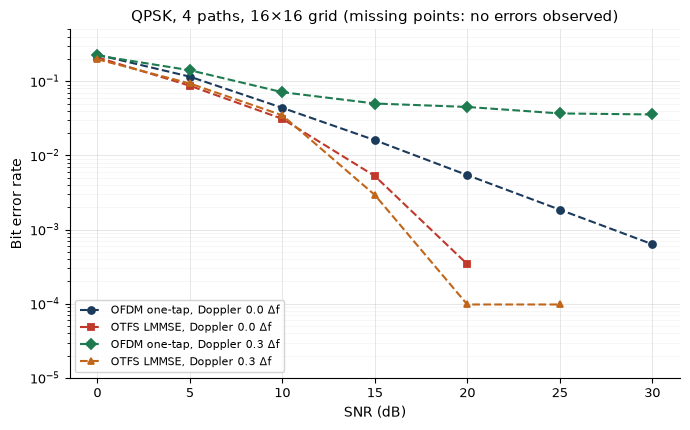

In [3]:
M, N = 16, 16                        # delay bins (subcarriers) x Doppler bins (symbols)
MN = M * N
FN = np.fft.fft(np.eye(N)) / np.sqrt(N)

def paths(n_paths, max_delay, nu_max, r):
    """Random paths; Doppler in units of the OFDM subcarrier spacing (1/M cycles/sample)."""
    l = np.sort(r.integers(0, max_delay + 1, n_paths)); l[0] = 0
    nu = r.uniform(-nu_max, nu_max, n_paths) / M
    h = (r.standard_normal(n_paths) + 1j * r.standard_normal(n_paths)) / np.sqrt(2 * n_paths)
    return l, nu, h

def channel_matrix(l, nu, h, L):
    """Time-domain channel on an L-sample block with a cyclic prefix (circular delays)."""
    n = np.arange(L)
    H = np.zeros((L, L), dtype=complex)
    for lp, vp, hp in zip(l, nu, h):
        H += hp * np.exp(2j * np.pi * vp * n)[:, None] * np.roll(np.eye(L), lp, axis=0)
    return H

A_otfs = np.kron(FN.conj().T, np.eye(M))      # vec(X F_N^H), column-major vec, X is M x N

def otfs_ber(snr_db, nu_max, trials=40, n_paths=4, max_delay=3):
    errs = bits = 0
    n0 = 10 ** (-snr_db / 10)
    for _ in range(trials):
        l, nu, h = paths(n_paths, max_delay, nu_max, rng)
        Heff = A_otfs.conj().T @ channel_matrix(l, nu, h, MN) @ A_otfs
        b = cl.random_bits(2 * MN, rng); x = qpsk.modulate(b)
        y = Heff @ x + np.sqrt(n0 / 2) * (rng.standard_normal(MN) + 1j * rng.standard_normal(MN))
        xh = np.linalg.solve(Heff.conj().T @ Heff + n0 * np.eye(MN), Heff.conj().T @ y)
        errs += np.sum(qpsk.demodulate(xh) != b); bits += len(b)
    return errs / bits

def ofdm_ber(snr_db, nu_max, trials=40, n_paths=4, max_delay=3, cp=4):
    """N OFDM symbols of M subcarriers, per-symbol CP, one-tap ZF with the symbol-average channel."""
    errs = bits = 0
    n0 = 10 ** (-snr_db / 10)
    L = M + cp
    for _ in range(trials):
        l, nu, h = paths(n_paths, max_delay, nu_max, rng)
        b = cl.random_bits(2 * MN, rng); X = qpsk.modulate(b).reshape(N, M)
        s = np.fft.ifft(X, axis=1) * np.sqrt(M)
        s = np.concatenate([s[:, -cp:], s], axis=1).ravel()
        n = np.arange(len(s))
        r = sum(hp * np.exp(2j * np.pi * vp * n) * np.roll(s, lp) for lp, vp, hp in zip(l, nu, h))
        r = r + np.sqrt(n0 / 2) * (rng.standard_normal(len(r)) + 1j * rng.standard_normal(len(r)))
        Y = np.fft.fft(r.reshape(N, L)[:, cp:], axis=1) / np.sqrt(M)
        k = np.arange(M)
        mid = np.arange(N)[:, None] * L + cp + M / 2
        Hk = sum(hp * np.exp(2j * np.pi * vp * mid) * np.exp(-2j * np.pi * k * lp / M) for lp, vp, hp in zip(l, nu, h))
        errs += np.sum(qpsk.demodulate((Y / Hk).ravel()) != b); bits += len(b)
    return errs / bits

snrs = np.arange(0, 31, 5.0)
sims = {}
for nu_max in [0.0, 0.3]:
    sims[f"OFDM one-tap, Doppler {nu_max} Δf"] = [ofdm_ber(s_, nu_max) for s_ in snrs]
    sims[f"OTFS LMMSE, Doppler {nu_max} Δf"] = [otfs_ber(s_, nu_max) for s_ in snrs]
f, ax = lk.fig("ber")
lk.ber_plot(ax, snrs, sims, xlabel="SNR (dB)", ylim=(1e-5, 0.5))
ax.set_title("QPSK, 4 paths, 16×16 grid (missing points: no errors observed)")
lk.show(f)

**What you should see.** OFDM with a one-tap equalizer has only single-path (Rayleigh) diversity:
its curve falls slowly and, with Doppler, flattens into an ICI floor. OTFS with a joint detector
harvests delay *and* Doppler diversity: a steeper slope, and Doppler costs it almost nothing.
**Fairness note:** the OTFS receiver is far more complex (a 256×256 solve here); an OFDM receiver with
ICI-aware equalization and coding across subcarriers would close much of the gap. That complexity
trade is one reason 6G studies keep CP-OFDM as the baseline (Chapter 25).

### The delay-Doppler channel is sparse
The OTFS effective channel's response to the symbol at (0, 0), reshaped onto the DD grid: each path
appears as a spike at its delay and Doppler.

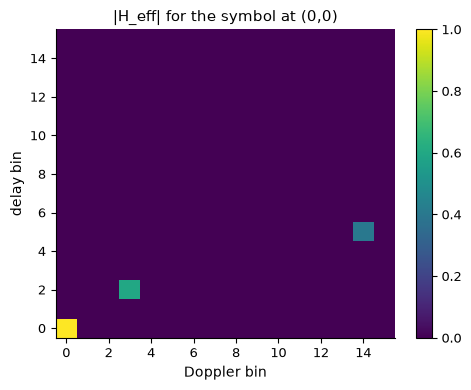

In [5]:
l, nu, h = np.array([0, 2, 5]), np.array([0.0, 3.0, -2.0]) / MN, np.array([1.0, 0.6, 0.4])
Heff = A_otfs.conj().T @ channel_matrix(l, nu, h, MN) @ A_otfs
col = Heff[:, 0].reshape(M, N, order="F")
f, ax = lk.fig((5, 4))
im = ax.imshow(np.abs(col), origin="lower", aspect="auto", cmap="viridis"); ax.grid(False)
ax.set_xlabel("Doppler bin"); ax.set_ylabel("delay bin"); ax.set_title("|H_eff| for the symbol at (0,0)")
plt.colorbar(im, ax=ax)
lk.show(f)

**What you should see.** Three bright cells at (delay, Doppler) = (0, 0), (2, 3) and (5, −2 ≡ 14):
the three paths, sitting exactly on the grid because their Dopplers are integer multiples of the
Doppler resolution.

## 2. ISAC: OFDM as a radar

Transmit known OFDM symbols $X[m,n]$ (subcarrier $m$, symbol $n$). A point target at range $R$ with
radial velocity $v$ returns

$$Y[m,n] = a\,X[m,n]\,e^{-j2\pi m\Delta f\,2R/c}\,e^{j2\pi nT_s\,2vf_c/c} + W.$$

Divide by $X$ to remove the data; an IFFT across subcarriers gives range and an FFT across symbols gives
velocity. Resolutions: $\Delta R = c/(2M\Delta f)$, $\Delta v = \lambda/(2NT_s)$.

### Interactive: a range–Doppler map at 28 GHz, NR numerology μ = 3

radar parameter,value
range resolution,2.44 m
maximum range,1250 m
velocity resolution,4.69 m/s
maximum |velocity|,300.3 m/s


[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

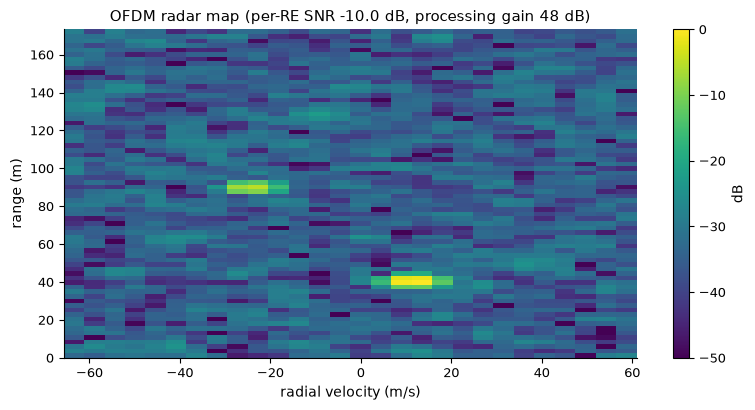

In [8]:
c0, fc = 3e8, 28e9
nr = cl.nr_numerology(3)
df = nr["scs_khz"] * 1e3
Ts = (nr["useful_symbol_us"] + nr["cp_us"]) * 1e-6
Mr, Nr = 512, 128
lam = c0 / fc
lk.table([["range resolution", f"{c0 / (2 * Mr * df):.2f} m"], ["maximum range", f"{c0 / (2 * df):.0f} m"],
          ["velocity resolution", f"{lam / (2 * Nr * Ts):.2f} m/s"], ["maximum |velocity|", f"{lam / (4 * Ts):.1f} m/s"]],
         ["radar parameter", "value"], title="OFDM radar with 512 subcarriers × 128 symbols at 120 kHz SCS")

def radar(r1=40.0, v1=12.0, r2=90.0, v2=-25.0, snr_db=-10.0):
    X = qpsk.modulate(cl.random_bits(2 * Mr * Nr, rng)).reshape(Mr, Nr)
    m = np.arange(Mr)[:, None]; n = np.arange(Nr)[None, :]
    Y = np.zeros_like(X)
    for R, v, a in [(r1, v1, 1.0), (r2, v2, 0.5)]:
        Y += a * X * np.exp(-2j * np.pi * m * df * 2 * R / c0) * np.exp(2j * np.pi * n * Ts * 2 * v * fc / c0)
    Y += np.sqrt(10 ** (-snr_db / 10) / 2) * (rng.standard_normal(Y.shape) + 1j * rng.standard_normal(Y.shape))
    Z = Y / X
    win = np.hanning(Mr)[:, None] * np.hanning(Nr)[None, :]
    RD = np.fft.fftshift(np.fft.fft(np.fft.ifft(Z * win, axis=0), axis=1), axes=1)
    P = lk.db(np.abs(RD) ** 2); P -= P.max()
    rng_axis = np.arange(Mr) * c0 / (2 * Mr * df)
    vel_axis = (np.arange(Nr) - Nr / 2) * lam / (2 * Nr * Ts)
    f, ax = lk.fig((8, 4.2))
    rmax, vw = 72, 14
    im = ax.imshow(P[:rmax, Nr // 2 - vw:Nr // 2 + vw], origin="lower", aspect="auto", vmin=-50, vmax=0, cmap="viridis",
                   extent=[vel_axis[Nr // 2 - vw], vel_axis[Nr // 2 + vw - 1], 0, rng_axis[rmax - 1]])
    ax.set_xlabel("radial velocity (m/s)"); ax.set_ylabel("range (m)"); ax.grid(False)
    ax.set_title(f"OFDM radar map (per-RE SNR {snr_db} dB, processing gain {10 * np.log10(Mr * Nr):.0f} dB)")
    plt.colorbar(im, ax=ax, label="dB")
    lk.show(f)

lk.interact(radar, r1=lk.slider(40, 0, 160, 1, "R1 (m)"), v1=lk.slider(12, -40, 40, 1, "v1 (m/s)"),
            r2=lk.slider(90, 0, 160, 1, "R2 (m)"), v2=lk.slider(-25, -40, 40, 1, "v2 (m/s)"),
            snr_db=lk.slider(-10, -40, 20, 2, "SNR per RE (dB)"))

**What you should see.** Two peaks at (12 m/s, 40 m) and (−25 m/s, 90 m), clearly above the floor even
though each resource element is 10 dB *below* the noise: the 2-D FFT gives $10\log_{10}(512\cdot128) = 48$ dB
of processing gain. The communication data is not wasted: dividing by the known $X$ removed it.

### Try it yourself 2.1
Keep 120 kHz subcarriers but use 3300 of them (about 400 MHz). What range resolution (m) results?

In [10]:
answer_2_1 = None
lk.check("2.1 range resolution with 3300 x 120 kHz", answer_2_1, c0 / (2 * 3300 * 120e3), rtol=0.01)

[TODO] 2.1 range resolution with 3300 x 120 kHz: not attempted yet: replace the None with your answer

## 3. Reconfigurable intelligent surfaces

An RIS is a passive panel of $N$ elements, each applying a controllable phase shift $\theta_i$ to the wave
it reflects. With a blocked direct path, the received signal is $y = \sum_i g_i e^{j\theta_i} h_i\, x + w$.
Choosing $\theta_i = -\angle(g_ih_i)$ aligns all $N$ reflections, so the amplitude grows as $N$ and the
**power as $N^2$**: coherent passive beamforming. The catch is the "double path loss": each
$|g_ih_i|$ is the product of two tiny path gains, so a practical RIS needs hundreds to thousands of
elements to beat a modest direct path. Real surfaces also have only a few phase states (1–2 bits).

### Interactive: element count and phase quantization

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

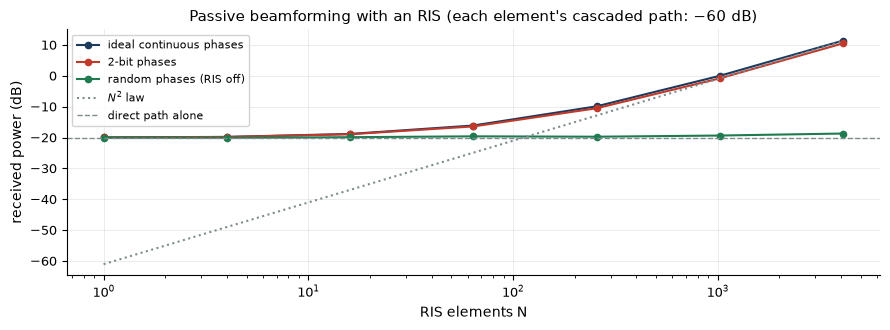

In [12]:
def ris_demo(bits_phase=2, direct_db=-20.0):
    Ns = np.array([1, 4, 16, 64, 256, 1024, 4096])
    out = {"ideal continuous phases": [], f"{bits_phase}-bit phases": [], "random phases (RIS off)": []}
    for Ni in Ns:
        acc = {k: [] for k in out}
        for _ in range(200):
            gh = (rng.standard_normal(Ni) + 1j * rng.standard_normal(Ni)) / np.sqrt(2)   # cascaded gains
            gh = gh * lk.undb(-60) ** 0.5                                              # double path loss
            d = lk.undb(direct_db) ** 0.5 * (rng.standard_normal() + 1j * rng.standard_normal()) / np.sqrt(2)
            th = np.angle(d) - np.angle(gh)                                            # align with direct path
            q = 2 * np.pi / 2 ** bits_phase
            acc["ideal continuous phases"].append(abs(d + np.sum(gh * np.exp(1j * th))) ** 2)
            acc[f"{bits_phase}-bit phases"].append(abs(d + np.sum(gh * np.exp(1j * q * np.round(th / q)))) ** 2)
            acc["random phases (RIS off)"].append(abs(d + np.sum(gh * np.exp(2j * np.pi * rng.random(Ni)))) ** 2)
        for k in out:
            out[k].append(lk.db(np.mean(acc[k])))
    f, ax = lk.fig("wide")
    for k, v in out.items():
        ax.semilogx(Ns, v, "o-", label=k)
    ax.semilogx(Ns, lk.db(Ns ** 2 * lk.undb(-60) * np.pi / 4), ":", color=lk.GRAY, label="$N^2$ law")
    ax.axhline(direct_db, color=lk.GRAY, ls="--", lw=1, label="direct path alone")
    ax.set_xlabel("RIS elements N"); ax.set_ylabel("received power (dB)"); ax.legend(fontsize=8)
    ax.set_title("Passive beamforming with an RIS (each element's cascaded path: −60 dB)")
    lk.show(f)

lk.interact(ris_demo, bits_phase=lk.islider(2, 1, 4, 1, "phase bits"), direct_db=lk.slider(-20, -80, 0, 5, "direct path (dB)"))

**What you should see.** With aligned phases the received power rises 20 dB per decade of elements
(the $N^2$ law) once the RIS dominates; random phases add power only incoherently ($\propto N$, 10 dB
per decade), too little to lift the curve off the direct path here.
2-bit phases cost about 0.9 dB, 1-bit about 3.9 dB. With the direct path at −20 dB, the RIS needs on the
order of a hundred elements just to match it.

## 4. A learned demapper for a nonlinear, phase-noisy transmitter

Model-based detection assumes the received constellation sits on the ideal grid. A saturated PA
(Rapp model) compresses the outer points and phase noise smears them in angle. A two-layer network
trained with cross-entropy learns the actual decision regions from pilot data. This is the simplest
instance of the "learned receiver" idea studied for 5G-Advanced and 6G (O'Shea and Hoydis, 2017;
NVIDIA Sionna provides industrial-strength tooling).

detector,SER at 20 dB
minimum distance (ideal grid),0.0958
learned demapper,0.0091


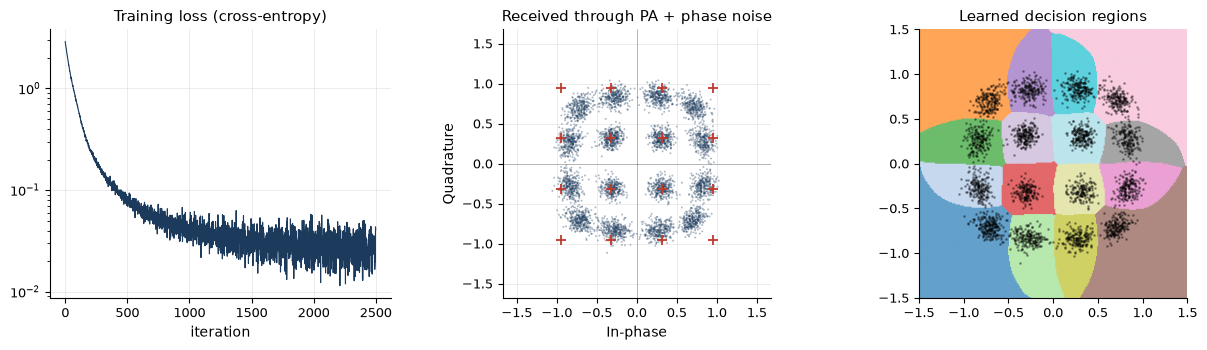

In [15]:
c16 = cl.get_constellation("16qam")

def impaired(idx, snr_db, sat=1.1, pn_deg=4.0):
    x = cl.rapp_pa(c16._lut[idx] * 1.0, sat=sat, p=2.0)
    x = x * np.exp(1j * np.deg2rad(pn_deg) * rng.standard_normal(len(x)))
    return cl.awgn_esn0(x, snr_db, rng=rng, es=1.0)[0]

def features(y):
    return np.stack([y.real, y.imag, np.abs(y), np.abs(y) ** 2], axis=1)

class MLP:
    """Two-layer perceptron (ReLU hidden layer, softmax output) trained with Adam."""

    def __init__(self, din, dh, dout, r):
        self.W1 = r.standard_normal((din, dh)) * np.sqrt(2 / din); self.b1 = np.zeros(dh)
        self.W2 = r.standard_normal((dh, dout)) * np.sqrt(1 / dh); self.b2 = np.zeros(dout)
        self.params = [self.W1, self.b1, self.W2, self.b2]
        self.m = [np.zeros_like(p) for p in self.params]; self.v = [np.zeros_like(p) for p in self.params]
        self.t = 0

    def forward(self, X):
        self.X = X; self.Z = X @ self.W1 + self.b1; self.Hh = np.maximum(self.Z, 0)
        return self.Hh @ self.W2 + self.b2

    def step(self, logits, labels, lr=3e-3):
        p = np.exp(logits - logits.max(1, keepdims=True)); p /= p.sum(1, keepdims=True)
        g = p.copy(); g[np.arange(len(labels)), labels] -= 1; g /= len(labels)
        grads = [self.X.T @ (g @ self.W2.T * (self.Z > 0)), (g @ self.W2.T * (self.Z > 0)).sum(0), self.Hh.T @ g, g.sum(0)]
        self.t += 1
        for i, (prm, gr) in enumerate(zip(self.params, grads)):
            self.m[i] = 0.9 * self.m[i] + 0.1 * gr; self.v[i] = 0.999 * self.v[i] + 0.001 * gr ** 2
            prm -= lr * (self.m[i] / (1 - 0.9 ** self.t)) / (np.sqrt(self.v[i] / (1 - 0.999 ** self.t)) + 1e-8)
        return -np.mean(np.log(p[np.arange(len(labels)), labels] + 1e-12))

snr_train = 20.0
net = MLP(4, 64, 16, rng)
losses = []
for it in range(2500):
    idx = rng.integers(0, 16, 512)
    losses.append(net.step(net.forward(features(impaired(idx, snr_train))), idx))

idx = rng.integers(0, 16, 60_000)
y = impaired(idx, snr_train)
ser_std = np.mean(c16.nearest(y) != idx)
ser_nn = np.mean(np.argmax(net.forward(features(y)), 1) != idx)
lk.table([["minimum distance (ideal grid)", ser_std], ["learned demapper", ser_nn]],
         ["detector", f"SER at {snr_train:.0f} dB"], fmt={1: ".4f"})
f, ax = lk.fig("row3", 1, 3)
ax[0].plot(losses, lw=0.8); ax[0].set_yscale("log"); ax[0].set_title("Training loss (cross-entropy)"); ax[0].set_xlabel("iteration")
lk.constellation(ax[1], y[:6000], c16.points, "Received through PA + phase noise", s=2)
g = np.linspace(-1.5, 1.5, 250); Xg, Yg = np.meshgrid(g, g)
reg = np.argmax(net.forward(features((Xg + 1j * Yg).ravel())), 1).reshape(Xg.shape)
ax[2].imshow(reg, extent=[-1.5, 1.5, -1.5, 1.5], origin="lower", cmap="tab20", alpha=0.7); ax[2].grid(False)
ax[2].scatter(y[:3000].real, y[:3000].imag, s=1, c="k", alpha=0.3)
ax[2].set_title("Learned decision regions")
lk.show(f)

**What you should see.** The received constellation is compressed at the corners and rotated in
arcs; the learned decision regions bend to follow it, and the learned demapper's SER is several times
lower than the minimum-distance detector's. **Honest note:** a model-based receiver that knows the PA
curve (pre-distortion or a warped grid) would do as well; learning pays when the impairment is hard to model.

## Key takeaways
* Delay-Doppler modulation (OTFS, AFDM) turns a fast-varying channel into a sparse, stable one and
  harvests full diversity, at a receiver-complexity price.
* An OFDM waveform is also a radar: resolution $c/(2B)$ in range and $\lambda/(2T_{\text{obs}})$ in velocity.
* An RIS gives $N^2$ passive beamforming gain but pays a double path loss; it needs many elements.
* Learned receivers help where models are poor, and should always be compared with a good model-based baseline.

## Going further (hardware: USRP B200 / GNU Radio)
* Monostatic ISAC is hard with one B200 (TX-to-RX leakage), but a bistatic experiment works: transmit an
  OFDM frame from one radio and receive it with another, and watch a walking person's Doppler appear in
  the range–Doppler map of Section 2.
* Train the demapper of Section 4 on a real B200 loopback capture driven into compression (with an
  attenuator!) and compare with the simulation.

## Exercises
1. **(Warm-up)** Derive the OFDM radar range and velocity resolutions and the maximum unambiguous range
   and velocity. Which NR numerology gives the best velocity resolution for a fixed 1 ms frame?
2. **(Core)** Add an ICI-aware MMSE equalizer for OFDM (build the full per-symbol channel matrix). How
   much of the OTFS advantage remains?
3. **(Core)** Train the demapper to output bit LLRs (4 sigmoid outputs with binary cross-entropy) and
   measure coded BER with the LDPC code of Lab 9.
4. **(Stretch)** Implement AFDM: replace the OTFS modulation matrix with the inverse discrete affine
   Fourier transform $A^{-1} = \Lambda_{c_1}^H F^H \Lambda_{c_2}^H$, choose $c_1$ from the maximum Doppler,
   and compare BER and PAPR with OTFS.

In [18]:
lk.summary()

[good] Lab 12 finished in 11.2 s. Self-checks: 0 passed, 0 failed, 1 still to do.